In [1]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

### Pulling in the data

In [2]:
awards = pd.read_csv('data/data_sources_silver/wiki_and_trends_20260528.csv')
sales_scores = pd.read_csv('data/data_sources_gold/sales_scores.csv')
bgg_marketplace = pd.read_csv('data/data_sources_silver/bgg_and_marketplace_20260528.csv')

awards = awards.drop(columns=awards.columns[0], axis=1)
sales_scores = sales_scores.drop(columns=sales_scores.columns[0], axis=1)

In [3]:
# get rid of columns related to the marketplace data and drop duplicate rows

drop_cols = [
    'condition',
    'listing_date',
    'listing_year_month',
    'price_usd'
]

bgg_ratings = bgg_marketplace.iloc[:,1:].drop(columns=drop_cols).drop_duplicates()
bgg_ratings.head()

,id,game_name,publication_year,min_players,max_players,min_playtime,max_playtime,min_age,complexity,avg_rating,...,num_ratings,num_owned,num_comments,num_wanting,num_wishing,categories,mechanics,designers,publishers,families
0,224517,Brass: Birmingham,2018,2,4,60,120,14,3.8621,8.56401,...,58538,84099,7961,1746,21932,"Age of Reason, Economic, Industry / Manufactur...","Chaining, End Game Bonuses, Hand Management, I...","Gavan Brown, Matt Tolman, Martin Wallace","Roxley, Arclight Games, Board Game Rookie, Boa...","Cities: Birmingham (England), Components: Map ..."
89,342942,Ark Nova,2021,1,4,90,150,14,3.7967,8.54046,...,61132,88969,8078,1063,17786,"Animals, Card Game, Environmental","Contracts, End Game Bonuses, Events, Grid Cove...",Mathias Wigge,"Feuerland Spiele, Capstone Games, CMON Global ...","Animals: Okapi, Components: Hexagonal Tiles, C..."
179,161936,Pandemic Legacy: Season 1,2015,2,4,60,60,13,2.8279,8.50231,...,57400,89397,8605,813,15039,"Environmental, Medical","Action Points, Cooperative Game, Hand Manageme...","Rob Daviau, Matt Leacock","Z-Man Games, Asterion Press, Devir, Filosofia ...","Components: Map (Global Scale), Components: Mu..."
226,174430,Gloomhaven,2017,1,4,60,120,14,3.9192,8.53879,...,67170,104567,11724,1161,22312,"Adventure, Exploration, Fantasy, Fighting, Min...","Action Queue, Action Retrieval, Campaign / Bat...",Isaac Childres,"Cephalofair Games, Albi, Albi Polska, Arclight...","Category: Dungeon Crawler, Components: Map (Ci..."
520,397598,Dune: Imperium – Uprising,2023,1,6,60,120,13,3.5224,8.70045,...,18497,28509,2351,891,7872,"Movies / TV / Radio theme, Novel-based, Scienc...","Automatic Resource Growth, Card Play Conflict ...",Paul Dennen,"Dire Wolf, Arclight Games, Broadway Toys LTD, ...","Books: Dune, Game: Dune: Imperium, Misc: LongP..."


In [4]:
award_counts = pd.DataFrame(awards.groupby('clean_name')['award'].count()).reset_index()

In [5]:
award_counts.shape, sales_scores.shape, bgg_ratings.shape

((386, 2), (25401, 13), (40112, 21))

In [6]:
award_counts.columns, sales_scores.columns, bgg_ratings.columns

(Index(['clean_name', 'award'], dtype='object'),
 Index(['id', 'total_sales', 'months_active', 'monthly_avg_sales',
        'sales_score_0.375', 'sales_score_0', 'sales_score_0.125',
        'sales_score_0.25', 'sales_score_0.5', 'sales_score_0.625',
        'sales_score_0.75', 'sales_score_0.875', 'sales_score_1'],
       dtype='object'),
 Index(['id', 'game_name', 'publication_year', 'min_players', 'max_players',
        'min_playtime', 'max_playtime', 'min_age', 'complexity', 'avg_rating',
        'bayes_rating', 'num_ratings', 'num_owned', 'num_comments',
        'num_wanting', 'num_wishing', 'categories', 'mechanics', 'designers',
        'publishers', 'families'],
       dtype='object'))

### Join tables with bgg_ratings as the starting point or leftmost table

In [7]:
#helper function for stripping white space from names and matching it
#regrettably we need to use this to match the wiki/trends data
def name_cleaner(name):
    return (
        name.fillna('')
         .str.lower()
         #drop punctuation
         .str.replace(r'[^a-z0-9\s]', '', regex=True)
         #remove multiple white spaces
         .str.replace(r'\s+', ' ', regex=True)
         .str.strip()
    )

In [8]:
combined_df = pd.merge(left=bgg_ratings, right=sales_scores[['id','sales_score_0.375']], on='id', how='left')
combined_df = combined_df.rename(columns={'sales_score_0.375': 'sales_score'})

# add clean_name
combined_df.insert(
    loc=combined_df.columns.get_loc('game_name') + 1,
    column='clean_name',
    value=name_cleaner(combined_df['game_name'])
)

combined_df = pd.merge(left=combined_df, right=award_counts, on='clean_name', how='left')
combined_df.rename(columns={'award': 'award_count'}, inplace=True)
combined_df.head()

,id,game_name,clean_name,publication_year,min_players,max_players,min_playtime,max_playtime,min_age,complexity,...,num_comments,num_wanting,num_wishing,categories,mechanics,designers,publishers,families,sales_score,award_count
0,224517,Brass: Birmingham,brass birmingham,2018,2,4,60,120,14,3.8621,...,7961,1746,21932,"Age of Reason, Economic, Industry / Manufactur...","Chaining, End Game Bonuses, Hand Management, I...","Gavan Brown, Matt Tolman, Martin Wallace","Roxley, Arclight Games, Board Game Rookie, Boa...","Cities: Birmingham (England), Components: Map ...",82.185814,NaN
1,342942,Ark Nova,ark nova,2021,1,4,90,150,14,3.7967,...,8078,1063,17786,"Animals, Card Game, Environmental","Contracts, End Game Bonuses, Events, Grid Cove...",Mathias Wigge,"Feuerland Spiele, Capstone Games, CMON Global ...","Animals: Okapi, Components: Hexagonal Tiles, C...",78.419058,3.0
2,161936,Pandemic Legacy: Season 1,pandemic legacy season 1,2015,2,4,60,60,13,2.8279,...,8605,813,15039,"Environmental, Medical","Action Points, Cooperative Game, Hand Manageme...","Rob Daviau, Matt Leacock","Z-Man Games, Asterion Press, Devir, Filosofia ...","Components: Map (Global Scale), Components: Mu...",74.775606,0.0
3,174430,Gloomhaven,gloomhaven,2017,1,4,60,120,14,3.9192,...,11724,1161,22312,"Adventure, Exploration, Fantasy, Fighting, Min...","Action Queue, Action Retrieval, Campaign / Bat...",Isaac Childres,"Cephalofair Games, Albi, Albi Polska, Arclight...","Category: Dungeon Crawler, Components: Map (Ci...",97.022417,1.0
4,397598,Dune: Imperium – Uprising,dune imperium uprising,2023,1,6,60,120,13,3.5224,...,2351,891,7872,"Movies / TV / Radio theme, Novel-based, Scienc...","Automatic Resource Growth, Card Play Conflict ...",Paul Dennen,"Dire Wolf, Arclight Games, Broadway Toys LTD, ...","Books: Dune, Game: Dune: Imperium, Misc: LongP...",62.903291,NaN


## Normalize avg_rating, num_comments, and award_count

In [9]:
to_normalize = ['avg_rating', 'num_comments', 'award_count']
normalized_cols = [f'{col}_norm' for col in to_normalize]

for idx, col in enumerate(to_normalize):
    combined_df[normalized_cols[idx]] = (
        (combined_df[col] - combined_df[col].min()) / 
        (combined_df[col].max() - combined_df[col].min())
        * 100
    ).fillna(0)

### Set the weights, multiply each column, and take the sum of each row as the final success score.

In [10]:
weights = {
    'avg_rating_norm': 0.5,
    'sales_score': 0.2,
    'num_comments_norm': 0.2,
    'award_count_norm': 0.1
}

weighted_scores = (combined_df[weights.keys()] * weights.values())

combined_df['success_score'] = weighted_scores.sum(axis=1)
combined_df[['id', 'clean_name', 'sales_score'] + normalized_cols + ['success_score']].head()

,id,clean_name,sales_score,avg_rating_norm,num_comments_norm,award_count_norm,success_score
0,224517,brass birmingham,82.185814,85.6401,33.283164,0.0,65.913846
1,342942,ark nova,78.419058,85.4046,33.772315,37.5,68.890575
2,161936,pandemic legacy season 1,74.775606,85.0231,35.975584,0.0,64.661788
3,174430,gloomhaven,97.022417,85.3879,49.015427,12.5,73.151519
4,397598,dune imperium uprising,62.903291,87.0045,9.829006,0.0,58.048709


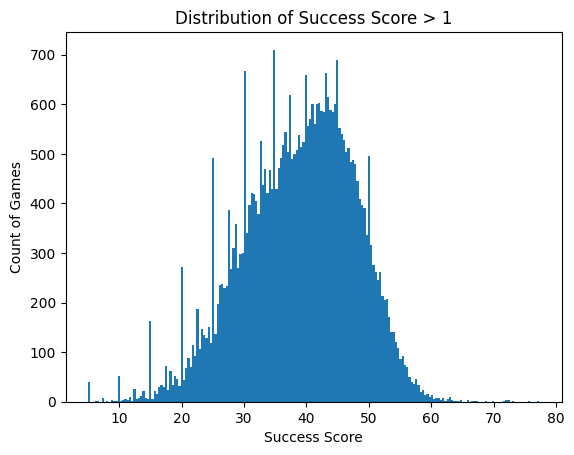

In [15]:
plt.hist(combined_df[(combined_df['success_score'] > 1) & (combined_df['avg_rating_norm'] > 1)]['success_score'], bins=200)
plt.title('Distribution of Success Score > 1')
plt.xlabel('Success Score')
plt.ylabel('Count of Games')
plt.savefig('Figures/success_distribution.png')

In [12]:
combined_df.sort_values(by='success_score', ascending=False)

,id,game_name,clean_name,publication_year,min_players,max_players,min_playtime,max_playtime,min_age,complexity,...,mechanics,designers,publishers,families,sales_score,award_count,avg_rating_norm,num_comments_norm,award_count_norm,success_score
37,266192,Wingspan,wingspan,2019,1,5,40,70,10,2.480700,...,"Action Queue, Dice Rolling, End Game Bonuses, ...",Elizabeth Hargrave,"Stonemaier Games, 999 Games, Angry Lion Games,...","Animals: Birds, Animals: Crows / Ravens / Magp...",80.230615,7.0,79.9843,62.594590,87.5,77.307191
8,167791,Terraforming Mars,terraforming mars,2016,1,5,120,120,12,3.271800,...,"Closed Drafting, Contracts, End Game Bonuses, ...",Jacob Fryxelius,"FryxGames, Arclight Games, Brädspel.se, Fantas...","Category: DIZED Tutorial, Components: Map (Glo...",83.983616,3.0,83.3611,66.390735,37.5,75.505420
3,174430,Gloomhaven,gloomhaven,2017,1,4,60,120,14,3.919200,...,"Action Queue, Action Retrieval, Campaign / Bat...",Isaac Childres,"Cephalofair Games, Albi, Albi Polska, Arclight...","Category: Dungeon Crawler, Components: Map (Ci...",97.022417,1.0,85.3879,49.015427,12.5,73.151519
63,31260,Agricola,agricola,2007,1,5,30,150,12,3.635300,...,"Automatic Resource Growth, Closed Drafting, En...",Uwe Rosenberg,"Lookout Games, 999 Games, Brain Games, Compaya...","Animals: Cattle / Cows, Animals: Horses, Anima...",84.694181,4.0,78.5762,59.617877,50.0,73.150512
170,30549,Pandemic,pandemic,2008,2,4,45,45,8,2.394200,...,"Action Points, Chaining, Contracts, Cooperativ...",Matt Leacock,"Z-Man Games, (Unknown), ADC Blackfire Entertai...","Components: Map (Global Scale), Components: Mu...",88.452166,NaN,75.1317,86.617334,0.0,72.579750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29377,40202,Junior Auto Race Game,junior auto race game,1928,2,4,30,30,0,0.842052,...,Simulation,(Uncredited),E. E. Fairchild Corporation,Sports: Auto Racing,NaN,NaN,0.0000,0.000000,0.0,0.000000
29386,40454,Le Défifoo bleu,le dfifoo bleu,2006,2,6,20,20,0,0.842052,...,Hand Management,Olivier Finet,Defifoo SA,Series: Défifoo,NaN,NaN,0.0000,0.000000,0.0,0.000000
34427,252771,Mucho Deck: Francais – English,mucho deck francais english,2018,2,6,10,30,3,0.842052,...,"Memory, Set Collection",NaN,(Self-Published),NaN,NaN,NaN,0.0000,0.000000,0.0,0.000000
29407,40686,Kleuren en figuren,kleuren en figuren,1995,1,2,15,15,2,0.842052,...,NaN,Micha Hertzano,Jumbo,Series: Tingo Das Eltern+Kind Spiel (Jumbo),NaN,NaN,0.0000,0.000000,0.0,0.000000


In [13]:
combined_df.to_csv('data/data_sources_gold/game_success_metrics.csv')

In [153]:
legend_labels

{'avg_rating_norm': 'BGG Rating',
 'sales_score': 'Sales Score',
 'num_comments_norm': 'BGG Comments',
 'award_count_norm': 'GotY Awards'}

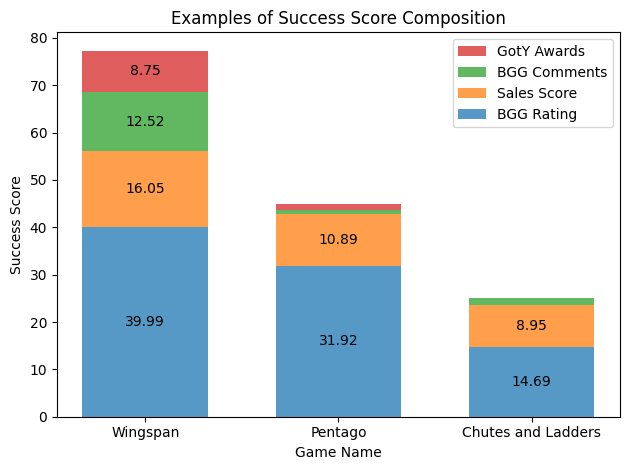

In [169]:
examples = [266192, 19841, 5432]
success_example = combined_df[combined_df['id'].isin(examples)][['game_name', 'avg_rating_norm', 'sales_score', 'num_comments_norm', 'award_count_norm']]
legend_labels = dict(zip(weights.keys(), ['BGG Rating', 'Sales Score', 'BGG Comments', 'GotY Awards']))

bottom=0

for column in weights.keys():
    values = success_example[column] * weights[column]
    bars = plt.bar(
        success_example['game_name'],
        success_example[column] * weights[column],
        bottom=bottom,
        alpha=0.75,
        width=0.65,
        label=legend_labels[column]
    )
    labels = [f'{v:.2f}' if v > 2 else '' for v in values]
    plt.bar_label(bars, labels=labels, label_type='center', fmt='%.2f')
    bottom += success_example[column] * weights[column]

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])

plt.title('Examples of Success Score Composition')
plt.xlabel('Game Name')
plt.ylabel('Success Score')
plt.tight_layout()

plt.savefig('Figures/success_composition_examples.png')
plt.show()